### Churn Prediction (Evaluation Metrics)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### 4.1 Data Preparation 

In [2]:
data = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv.xls")
df = data
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [3]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
cat_cols = list(df.dtypes[df.dtypes == 'object'].index)

for i in cat_cols:
    df[i] = df[i].str.lower().str.replace(' ', '_')   # Ensuring uniformity in data columns

In [4]:
df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')  ##
df.totalcharges = df.totalcharges.fillna(0) ##

In [5]:
df.churn.head()   # churn variable

0     no
1     no
2    yes
3     no
4    yes
Name: churn, dtype: object

In [6]:
(df.churn == 'yes').head()

0    False
1    False
2     True
3    False
4     True
Name: churn, dtype: bool

In [7]:
(df.churn == 'yes').astype(int).head()

0    0
1    0
2    1
3    0
4    1
Name: churn, dtype: int64

In [8]:
df.churn = (df.churn == 'yes').astype(int)  # Replacing churn with 0 or 1

#### 4.2 Setting Up Validation Framework

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
df_full_train, df_test =train_test_split(df, test_size = 0.2, random_state = 1) 

df_train, df_val = train_test_split(df_full_train, test_size = 0.25, random_state = 1)

In [11]:
len(df_train), len(df_test), len(df_val)

(4225, 1409, 1409)

In [12]:
df_train = df_train.reset_index(drop = True)
df_test = df_test.reset_index(drop = True)
df_val = df_val.reset_index(drop = True)

In [13]:
y_train = df_train.churn.values
y_test = df_test.churn.values
y_val  = df_val.churn.values

#### 4.3 EDA

##### Extracting numerical & categorical variables

In [14]:
numerical = ['tenure','monthlycharges', 'totalcharges']

In [15]:
categorical = ['gender', 'seniorcitizen', 'partner', 'dependents',
        'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod']

In [16]:
df_full_train[categorical].head()

,gender,seniorcitizen,partner,dependents,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod
1814,male,0,yes,yes,yes,no,no,no_internet_service,no_internet_service,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check
5946,female,0,no,no,yes,no,dsl,yes,yes,yes,yes,no,yes,one_year,no,credit_card_(automatic)
3881,male,0,yes,no,yes,yes,dsl,yes,yes,no,yes,no,no,two_year,no,bank_transfer_(automatic)
2389,male,0,yes,yes,yes,yes,dsl,yes,no,yes,yes,yes,yes,one_year,no,electronic_check
3676,male,0,no,no,yes,no,dsl,yes,yes,no,yes,yes,no,one_year,no,electronic_check


In [17]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

In [18]:
dv = DictVectorizer(sparse = False)

train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

In [19]:
model = LogisticRegression()
model.fit(X_train, y_train)

/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [20]:
val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

y_pred = model.predict_proba(X_val)[:,1] # probability of churning
churn_decision = (y_pred >= 0.5)
(y_val == churn_decision).mean() # checking model correctness

np.float64(0.8034066713981547)

#### 4.4 Accuracy

In [21]:
from sklearn.metrics import accuracy_score

In [22]:
accuracy_score(y_val, y_pred >= 0.5)

0.8034066713981547

In [23]:
threshold = np.linspace(0,1,21)

scores = []

for i in threshold:
    churn_decision = (y_pred >= i)
    score = accuracy_score(y_val, y_pred >= i)
    print('%.2f %.3f' %(i, score))
    scores.append(score)

0.00 0.274
0.05 0.509
0.10 0.591
0.15 0.666
0.20 0.710
0.25 0.739
0.30 0.760
0.35 0.772
0.40 0.785
0.45 0.793
0.50 0.803
0.55 0.801
0.60 0.795
0.65 0.786
0.70 0.766
0.75 0.744
0.80 0.735
0.85 0.726
0.90 0.726
0.95 0.726
1.00 0.726


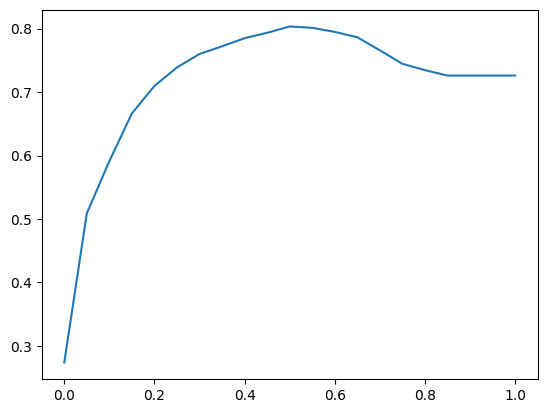

In [24]:
plt.plot(threshold, scores)

In [25]:
1- y_val.mean()  # Customers not churning

np.float64(0.7260468417317246)

#### 4.5 Confusion table

In [26]:
actual_positive = (y_val == 1)
actual_negative = (y_val == 0)

In [27]:
t = 0.5
predicted_positive = (y_pred >= t)
predicted_negative = (y_pred < t)

In [28]:
tp = (actual_positive & predicted_positive).sum() 
tp

np.int64(210)

In [29]:
tn = (actual_negative & predicted_negative).sum()
tn

np.int64(922)

In [30]:
fp = (actual_negative & predicted_positive).sum()
fp

np.int64(101)

In [31]:
fn = (actual_positive & predicted_negative).sum()
fn

np.int64(176)

In [32]:
confusion_matrix = np.array([[tn, fp],
                            [fn, tp]])

confusion_matrix 

# tn + tp = accuracy 

array([[922, 101],
       [176, 210]])

In [33]:
(confusion_matrix / confusion_matrix.sum()).round(2)

array([[0.65, 0.07],
       [0.12, 0.15]])

#### 4.6 Precision & Recall

Precision is the fraction of correct positive predictions while recall is the fraction of churning users predicted correctly

In [34]:
prec = tp/(tp+fp)
prec              # It means we were able to correcly identify 68% of churning customers

np.float64(0.6752411575562701)

In [35]:
rec = tp/(tp+fn)
rec              # It means we failed to identify 54% of churning customers

np.float64(0.5440414507772021)

#### 4.7 ROC Curves

In binary classification, ROC Curves help to visualize how best our model is performing

##### True Positive Rates (TPR) & False Positive Rates (FPR) --> ROC Curves look at all possible thresholds

In [36]:
TPR = tp/(tp+fn)  # TPR is the same as the recall
TPR

np.float64(0.5440414507772021)

In [37]:
FPR = fp/(fp+tn)
FPR

np.float64(0.09872922776148582)

In [38]:
scores = []

threshold = np.linspace(0,1,101)

for t in threshold:
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)

    predicted_positive = (y_pred >= t)
    predicted_negative = (y_pred < t)

    tp = (actual_positive & predicted_positive).sum()
    tn = (actual_negative & predicted_negative).sum()

    fp = (actual_negative & predicted_positive).sum()
    fn = (actual_positive & predicted_negative).sum()

    scores.append((t, tp, tn, fp, fn))

In [39]:
columns = ['threshold', 'tp','tn','fp','fn']
df_scores = pd.DataFrame(scores, columns= columns)

In [40]:
df_scores['TPR'] = df_scores.tp / (df_scores.tp + df_scores.fn)
df_scores['FPR'] = df_scores.fp / (df_scores.fp + df_scores.tn)

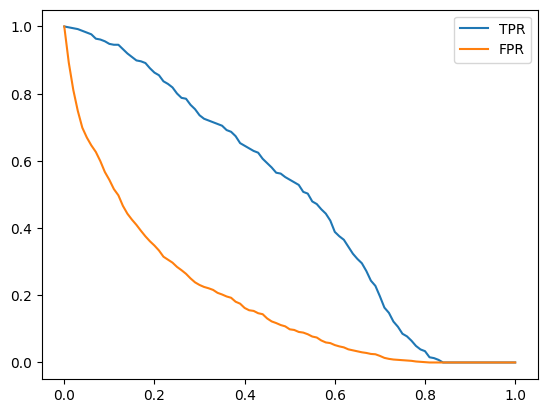

In [41]:
plt.plot(df_scores.threshold, df_scores['TPR'], label = 'TPR')
plt.plot(df_scores.threshold, df_scores['FPR'], label = 'FPR')
plt.legend()

#### Random Model

In [42]:
np.random.seed(1)
y_rand = np.random.uniform(0, 1, size = len(y_val))

In [43]:
((y_rand >= 0.5) == y_val).mean()

np.float64(0.5017743080198722)

In [44]:
def tpr_fpr_df(y_val, y_pred):

    scores = []

    threshold = np.linspace(0,1,101)
    
    for t in threshold:
        actual_positive = (y_val == 1)
        actual_negative = (y_val == 0)

        predicted_positive = (y_pred >= t)
        predicted_negative = (y_pred <= t)

        tp = (actual_positive & predicted_positive).sum()
        tn = (actual_negative & predicted_negative).sum()

        fp = (actual_negative & predicted_positive).sum()
        fn = (actual_positive & predicted_negative).sum()

        scores.append((t, tp, tn, fp, fn))

    columns = ['threshold', 'tp','tn','fp','fn']
    df_scores = pd.DataFrame(scores, columns= columns)
    df_scores['TPR'] = df_scores.tp / (df_scores.tp + df_scores.fn)
    df_scores['FPR'] = df_scores.fp / (df_scores.fp + df_scores.tn)

    return df_scores

In [45]:
df_rand = tpr_fpr_df(y_val, y_rand)

In [46]:
df_rand

,threshold,tp,tn,fp,fn,TPR,FPR
0,0.00,386,0,1023,0,1.000000,1.000000
1,0.01,382,10,1013,4,0.989637,0.990225
2,0.02,379,30,993,7,0.981865,0.970674
3,0.03,375,44,979,11,0.971503,0.956989
4,0.04,372,54,969,14,0.963731,0.947214
...,...,...,...,...,...,...,...
96,0.96,14,982,41,372,0.036269,0.040078
97,0.97,11,987,36,375,0.028497,0.035191
98,0.98,8,1004,19,378,0.020725,0.018573
99,0.99,6,1016,7,380,0.015544,0.006843


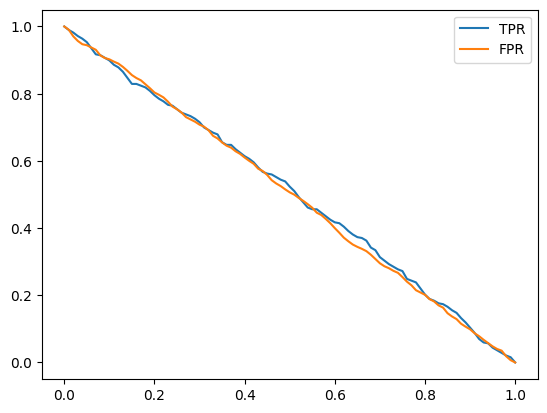

In [47]:
plt.plot(df_rand.threshold, df_rand['TPR'], label = 'TPR')
plt.plot(df_rand.threshold, df_rand['FPR'], label = 'FPR')
plt.legend()

#### Ideal Model

In [48]:
non_churning = (y_val == 0).sum()
churning = (y_val == 1).sum()
non_churning, churning

(np.int64(1023), np.int64(386))

In [49]:
y_ideal = np.repeat([0,1], [non_churning, churning])
y_ideal

array([0, 0, 0, ..., 1, 1, 1])

In [50]:
y_idealpred = np.linspace(0,1, len(y_val))
y_idealpred

array([0.00000000e+00, 7.10227273e-04, 1.42045455e-03, ...,
       9.98579545e-01, 9.99289773e-01, 1.00000000e+00])

In [51]:
1- y_val.mean()

np.float64(0.7260468417317246)

In [52]:
((y_idealpred >= 0.726) == y_ideal).mean()

np.float64(1.0)

In [53]:
df_ideal = tpr_fpr_df(y_ideal, y_idealpred)
df_ideal

,threshold,tp,tn,fp,fn,TPR,FPR
0,0.00,386,1,1023,0,1.000000,0.999023
1,0.01,386,15,1008,0,1.000000,0.985337
2,0.02,386,29,994,0,1.000000,0.971652
3,0.03,386,43,980,0,1.000000,0.957967
4,0.04,386,57,966,0,1.000000,0.944282
...,...,...,...,...,...,...,...
96,0.96,57,1023,0,329,0.147668,0.000000
97,0.97,43,1023,0,343,0.111399,0.000000
98,0.98,29,1023,0,357,0.075130,0.000000
99,0.99,15,1023,0,371,0.038860,0.000000


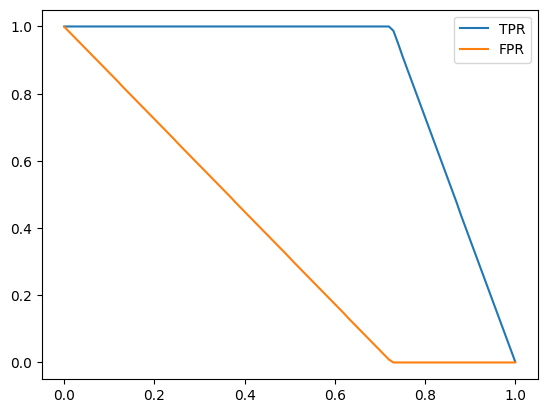

In [54]:
plt.plot(df_ideal.threshold, df_ideal['TPR'], label = 'TPR')
plt.plot(df_ideal.threshold, df_ideal['FPR'], label = 'FPR')
plt.legend()

The model shows correctly churning customers, especially when it crosses the 0.726 threshold

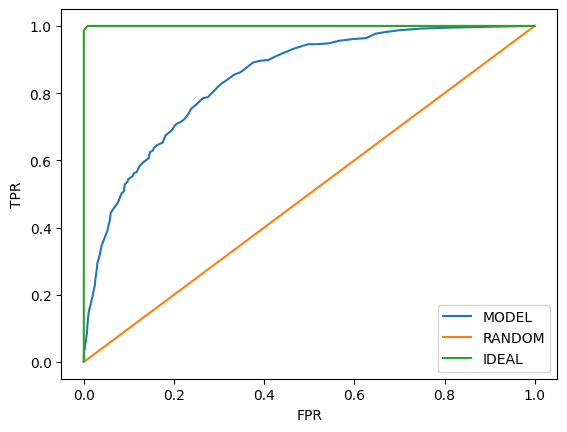

In [55]:
plt.plot(df_scores.FPR, df_scores.TPR, label = 'MODEL')
plt.plot([0,1], [0,1], label = 'RANDOM')
#plt.plot(df_rand.FPR, df_rand.TPR, label = 'RANDOM')
plt.plot(df_ideal.FPR, df_ideal.TPR, label = 'IDEAL')

plt.xlabel('FPR')
plt.ylabel('TPR')

plt.legend()

# The closer our 'model' is to the 'ideal' model, the better the prediction and vice-versa

The area under the curve is called AUC --> Area Under Curve. It tells how good our model is

#### Construcing ROC curves using the scikit-learn package

In [56]:
from sklearn.metrics import roc_curve

In [57]:
FPR, TPR, threshold = roc_curve(y_val, y_pred)

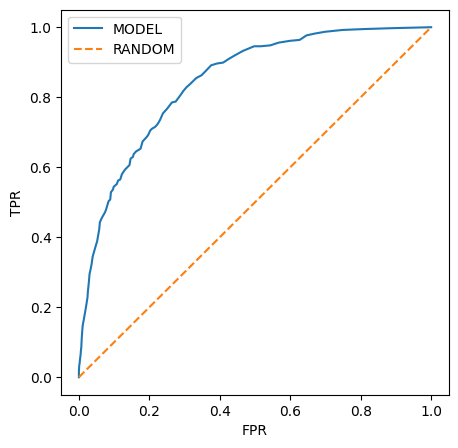

In [58]:
plt.figure(figsize=(5,5))

plt.plot(df_scores.FPR, df_scores.TPR, label = 'MODEL')
plt.plot([0,1], [0,1], label = 'RANDOM', linestyle ='--')

plt.xlabel('FPR')
plt.ylabel('TPR')

plt.legend()

#### 4.8 AUC

Measuring the 'Area' 'Under' the ROC curve tells how good our model is.
The closer our model is to the ideal spot, the better it is

In [59]:
from sklearn.metrics import auc

In [60]:
auc(FPR, TPR)

np.float64(0.8438201165929731)

In [61]:
auc(df_ideal.FPR, df_ideal.TPR)  # We calculate the ideal area

np.float64(0.9989664578759136)

In [62]:
from sklearn.metrics import roc_auc_score  # Simpler AUC calculation

In [63]:
roc_auc_score(y_val, y_pred)

np.float64(0.8438201165929731)

The area under the curve for the ideal spot (0.99) is quite close to that of the model (0.84), which is a good score. This however, can be fine-tuned further to enhance prediction. 

#### 4.9 Cross-Validation 

This highlights parameter tuning, the process of selecting the best parameter.
Here, we use the validation set to find the best parameter for training the model

In [64]:
def train(df_train, y_train, C=1.0):
    dicts = df_train[categorical + numerical].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(C=C, max_iter=1000)
    model.fit(X_train, y_train)

    return dv, model

In [65]:
dv, model = train(df_train, y_train, C= 0.001)

In [66]:
def predict(df_train,dv, model):
    dicts = df_train[categorical + numerical].to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

In [67]:
y_pred = predict(df_val, dv, model)

In [68]:
from sklearn.model_selection import KFold

In [69]:
#kfold = KFold(n_splits=10, random_state=1, shuffle=True)

In [70]:
from tqdm.auto import tqdm

In [ ]:
n_splits = 5

for C in tqdm([0.001, 0.01, 0.1, 0.5, 1, 5, 10]):
    kfold = KFold(n_splits= n_splits, random_state=1, shuffle=True)

    scores = []

    for train_ind, val_ind in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_ind]
        df_val = df_full_train.iloc[val_ind]
    
        y_train = df_train.churn.values
        y_val = df_val.churn.values
    
        dv, model = train(df_train, y_train)
        y_pred = predict(df_val, dv, model)
    
        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

    print('%s, %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))

  0%|          | 0/7 [00:00<?, ?it/s]

/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-re

0.001, 0.842 +- 0.007


/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-re

0.01, 0.842 +- 0.007


/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-re

0.1, 0.842 +- 0.007


/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-re

0.5, 0.842 +- 0.007


In [ ]:
scores

In [ ]:
dv, model = train(df_full_train, df_full_train.churn.values, C= 1.0)
y_pred = predict(df_test, dv, model)

auc = roc_auc_score(y_test, y_pred)
auc